<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana12/RegressaoLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


,target
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


,count
target,
1,357
0,212


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC AUC Score (Área sob a curva): 0.0023

Como o modelo toma a decisão (Primeiros 5 casos):
   Real  Previsao_Classe  Certeza_do_Modelo (%)
0     1                1              12.365650
1     0                0              99.999997
2     0                0              99.838892
3     1                1               0.126667
4     1                1               0.014959


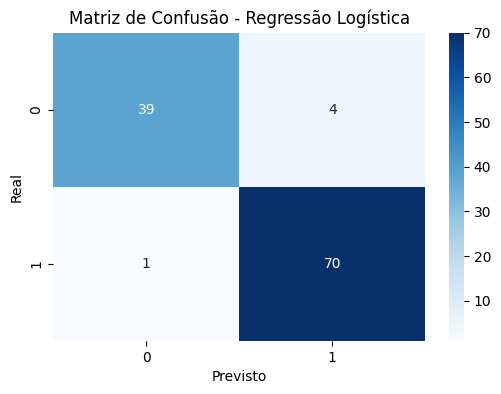

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Dataset de Câncer de Mama nativo do Sklearn
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.frame

# Alvo: 0 (Maligno), 1 (Benigno)
X = df_cancer.drop('target', axis=1)
y = df_cancer['target']

display(X.head(10))
display(y.head(10))

display(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinamento (Aumentando max_iter por segurança)
modelo_log = LogisticRegression(max_iter=3000)
modelo_log.fit(X_train, y_train)

# Previsões de Classe e de Probabilidades
y_pred = modelo_log.predict(X_test)
probabilidades = modelo_log.predict_proba(X_test)[:, 0] # Pegando apenas a prob da classe 0

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score (Área sob a curva): {roc_auc_score(y_test, probabilidades):.4f}\n")

# Mostrando aos alunos o poder da probabilidade
df_resultados = pd.DataFrame({
    'Real': y_test.values,
    'Previsao_Classe': y_pred,
    'Certeza_do_Modelo (%)': probabilidades * 100
})
print("Como o modelo toma a decisão (Primeiros 5 casos):")
print(df_resultados.head())

# Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Regressão Logística")
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

--- INTERPRETAÇÃO DE NEGÓCIOS (ODDS RATIO) ---
  Variável  Peso_Matematico (Beta)  Odds Ratio  Impacto no Risco (%)
Gravidezes                  0.1134      1.1201               12.0089
       IMC                  0.0829      1.0864                8.6449
   Glicose                  0.0332      1.0338                3.3756
     Idade                  0.0129      1.0130                1.2991
--------------------------------------------------


/tmp/ipykernel_4168/3171725151.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Impacto no Risco (%)', y='Variável', data=df_interpretacao, palette=cores)


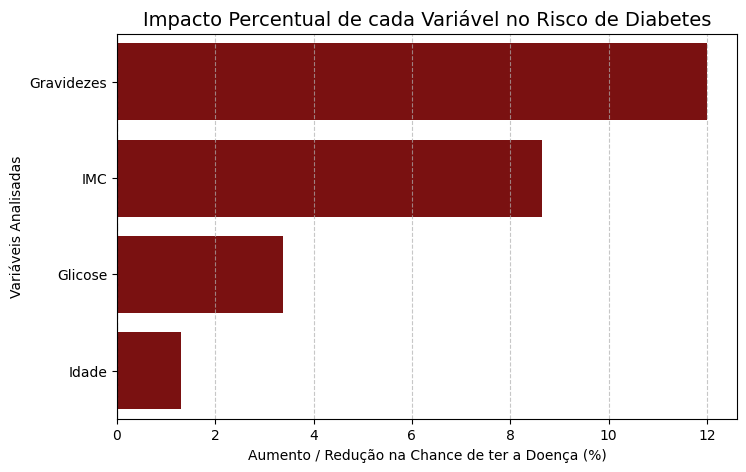

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# 1. Carregar os dados (Dataset de Diabetes da Aula 2)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
colunas = ['Gravidezes', 'Glicose', 'Pressao', 'Pele', 'Insulina', 'IMC', 'Pedigree', 'Idade', 'Target']
df = pd.read_csv(url, names=colunas)

# Vamos selecionar 4 variáveis fáceis de explicar para a turma
X = df[['Gravidezes', 'Glicose', 'IMC', 'Idade']]
y = df['Target']

# 2. Treinar o modelo
# NOTA PEDAGÓGICA: Não estamos escalonando os dados (StandardScaler) de propósito.
# Se escalonarmos, a interpretação muda para "por desvio padrão". Sem escalonar,
# a interpretação fica literal: "a cada 1 ano de idade", "a cada 1 unidade de IMC".
modelo_log = LogisticRegression()
modelo_log.fit(X, y)

# 3. O Pulo do Gato: Calculando o Odds Ratio
coeficientes = modelo_log.coef_[0]        # Os pesos originais (Log-Odds)
odds_ratios = np.exp(coeficientes)        # Aplicando e^beta (A Mágica!)
impacto_percentual = (odds_ratios - 1) * 100 # Convertendo para % de aumento/queda

# 4. Criando um DataFrame amigável para o negócio
df_interpretacao = pd.DataFrame({
    'Variável': X.columns,
    'Peso_Matematico (Beta)': coeficientes,
    'Odds Ratio': odds_ratios,
    'Impacto no Risco (%)': impacto_percentual
})

# Ordenar do maior para o menor impacto
df_interpretacao = df_interpretacao.sort_values(by='Odds Ratio', ascending=False)
print("--- INTERPRETAÇÃO DE NEGÓCIOS (ODDS RATIO) ---")
print(df_interpretacao.to_string(index=False, float_format="%.4f"))
print("-" * 50)

# 5. Visualização: Gráfico de Impacto
plt.figure(figsize=(8, 5))
cores = ['darkred' if valor > 0 else 'darkgreen' for valor in df_interpretacao['Impacto no Risco (%)']]

sns.barplot(x='Impacto no Risco (%)', y='Variável', data=df_interpretacao, palette=cores)
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.title('Impacto Percentual de cada Variável no Risco de Diabetes', fontsize=14)
plt.xlabel('Aumento / Redução na Chance de ter a Doença (%)')
plt.ylabel('Variáveis Analisadas')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

--- INTERPRETAÇÃO (Base de Comparação: ZERO Gravidezes) ---
          Variável  Odds Ratio  Impacto no Risco (%)
Gravidez_4_ou_Mais        1.54                 54.11
               IMC        1.09                  8.60
           Glicose        1.03                  3.32
             Idade        1.02                  1.97
    Gravidez_2_a_3        1.02                  1.95
  Gravidez_1_Unica        0.74                -26.32
-------------------------------------------------------


/tmp/ipykernel_4168/1816995335.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Impacto no Risco (%)', y='Variável', data=df_interpretacao, palette=cores)


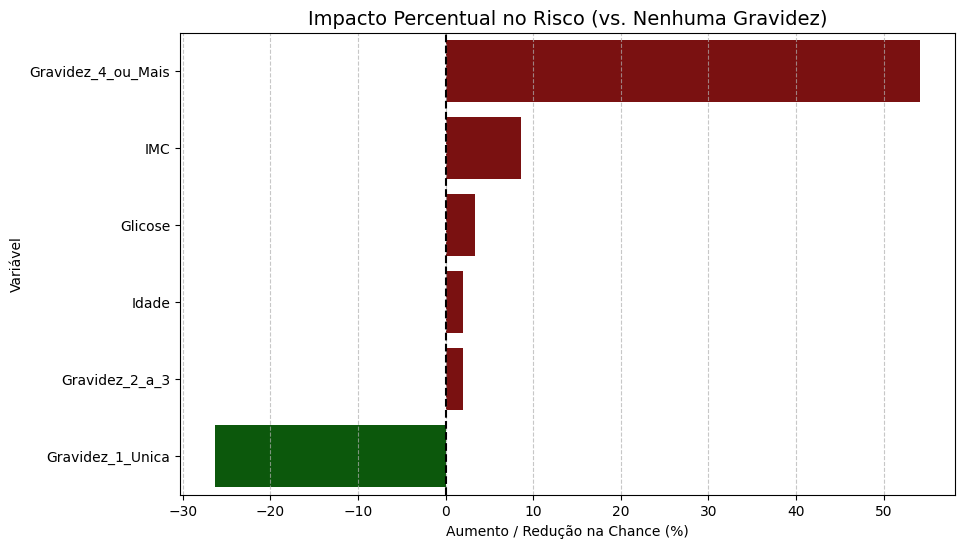

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# 1. Carregar os dados
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
colunas = ['Gravidezes', 'Glicose', 'Pressao', 'Pele', 'Insulina', 'IMC', 'Pedigree', 'Idade', 'Target']
df = pd.read_csv(url, names=colunas)

# 2. Transformar Gravidezes em Categorias Lógicas
# Não criamos de 1 a 15 para o modelo não ficar confuso. Agrupamos em faixas!
def categorizar_gravidez(g):
    if g == 0: return 'Gravidez_0_Nenhuma'
    elif g == 1: return 'Gravidez_1_Unica'
    elif g <= 3: return 'Gravidez_2_a_3'
    else: return 'Gravidez_4_ou_Mais'

df['Faixa_Gravidez'] = df['Gravidezes'].apply(categorizar_gravidez)

# 3. Criar as Variáveis Dummy
# O parâmetro drop_first=False cria todas as colunas.
# Vamos dropar manualmente a "Gravidez_0_Nenhuma" para ela ser a BASE de cálculo
df_dummies = pd.get_dummies(df['Faixa_Gravidez'], dtype=int)
df_dummies = df_dummies.drop('Gravidez_0_Nenhuma', axis=1)

# Montar o X final (Dummies + Restante)
X = pd.concat([df_dummies, df[['Glicose', 'IMC', 'Idade']]], axis=1)
y = df['Target']

# 4. Treinar o Modelo
modelo_log = LogisticRegression(max_iter=500)
modelo_log.fit(X, y)

# 5. Cálculo do Odds Ratio
coeficientes = modelo_log.coef_[0]
odds_ratios = np.exp(coeficientes)
impacto_percentual = (odds_ratios - 1) * 100

# 6. Tabela de Interpretação
df_interpretacao = pd.DataFrame({
    'Variável': X.columns,
    'Odds Ratio': odds_ratios,
    'Impacto no Risco (%)': impacto_percentual
})

df_interpretacao = df_interpretacao.sort_values(by='Impacto no Risco (%)', ascending=False)
print("--- INTERPRETAÇÃO (Base de Comparação: ZERO Gravidezes) ---")
print(df_interpretacao.to_string(index=False, float_format="%.2f"))
print("-" * 55)

# 7. Visualização Gráfica
plt.figure(figsize=(10, 6))
cores = ['darkred' if v > 0 else 'darkgreen' for v in df_interpretacao['Impacto no Risco (%)']]

sns.barplot(x='Impacto no Risco (%)', y='Variável', data=df_interpretacao, palette=cores)
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.title('Impacto Percentual no Risco (vs. Nenhuma Gravidez)', fontsize=14)
plt.xlabel('Aumento / Redução na Chance (%)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()